## Part I: Data Profiling ##

In [376]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [377]:
#Read CSV
employee_df = pd.read_csv("/Users/janekaporter/Documents/WGU Masters/Data Preparation and Exploration/Task 1/Employee Turnover Dataset.csv")
employee_df.columns = employee_df.columns.str.strip()

In [378]:
#Identify the dataset’s number of records

print(employee_df.shape)

(10199, 16)


In [379]:
#View dataset

print(employee_df.head())

   EmployeeNumber  Age  Tenure Turnover HourlyRate  HoursWeekly  \
0               1   28       6      Yes    $24.37            40   
1               2   33       2      Yes    $24.37            40   
2               3   22       1       No    $22.52            40   
3               4   23       1       No    $22.52            40   
4               5   40       6       No    $88.77            40   

  CompensationType  AnnualSalary  DrivingCommuterDistance  \
0           Salary       50689.6                       89   
1           Salary       50689.6                       89   
2           Salary       46841.6                       35   
3           Salary       46841.6                       35   
4           Salary      284641.6                       12   

              JobRoleArea                Gender MaritalStatus  \
0                Research                Female       Married   
1                Research                Female       Married   
2  Information_Technology          

## Part II: Data Cleaning and Plan ##

# Duplicate entries

In [380]:
# Check for duplicate rows

print(employee_df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
10194     True
10195     True
10196     True
10197     True
10198     True
Length: 10199, dtype: bool


In [381]:
#Count total duplicates

print(employee_df.duplicated().sum())

99


In [382]:
# Shows full duplicated row

duplicate_rows = employee_df[employee_df.duplicated(keep=False)]

In [383]:
# See which columns are actually duplicated by Employee Number

duplicate_rows.sort_values(by=["EmployeeNumber"])

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
0,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
10100,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
1,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
10101,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
2,3,22,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,1.0,8.0,Mailed Check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,97,44,6,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,6.0,NaN,Mail Check,Yes
10197,98,58,19,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,5.0,23.0,Mail Check,Yes
97,98,58,19,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,5.0,23.0,Mail Check,Yes
98,99,48,17,Yes,$71.33,40,Salary,148075.2,50,Sales,Prefer Not to Answer,Married,8.0,8.0,Mail Check,Yes


In [384]:
#Remove duplicate records for the dataset

employee_df = employee_df.drop_duplicates()

In [385]:
#Confirm duplicates were removed

employee_df.duplicated().sum()

0

In [386]:
#Identify new dataset’s number of records after dropping duplicates

print(employee_df.shape)

(10100, 16)


# Missing Values

In [387]:
#Check for missing values and count missing values using .any() or .sum()

print(employee_df.isnull().any())

print(employee_df.isnull().sum())

EmployeeNumber                  False
Age                             False
Tenure                          False
Turnover                        False
HourlyRate                      False
HoursWeekly                     False
CompensationType                False
AnnualSalary                    False
DrivingCommuterDistance         False
JobRoleArea                     False
Gender                          False
MaritalStatus                   False
NumCompaniesPreviouslyWorked     True
AnnualProfessionalDevHrs         True
PaycheckMethod                  False
TextMessageOptIn                 True
dtype: bool
EmployeeNumber                     0
Age                                0
Tenure                             0
Turnover                           0
HourlyRate                         0
HoursWeekly                        0
CompensationType                   0
AnnualSalary                       0
DrivingCommuterDistance            0
JobRoleArea                        0
Gender    

In [388]:
#Update missing values found in numerical columns NumCompaniesPreviouslyWorked and AnnualProfessionalDevHrs columns with mean values

employee_df['NumCompaniesPreviouslyWorked'].fillna(employee_df['NumCompaniesPreviouslyWorked'].mean(), inplace=True)
employee_df['AnnualProfessionalDevHrs'].fillna(employee_df['AnnualProfessionalDevHrs'].mean(), inplace=True)

In [389]:
#Clean mean values for NumCompaniesPreviouslyWorked to round as nearest whole number
employee_df["NumCompaniesPreviouslyWorked"] = employee_df["NumCompaniesPreviouslyWorked"].round(0)
employee_df["NumCompaniesPreviouslyWorked"] = employee_df["NumCompaniesPreviouslyWorked"].astype(int)

In [390]:
#Update missing values found in categorical column TextMessageOptIn with mode values

mode_text = employee_df["TextMessageOptIn"].mode()[0]
employee_df["TextMessageOptIn"] = employee_df["TextMessageOptIn"].fillna(mode_text)

In [391]:
#validate to check for missing values

print(employee_df.isnull().sum())

EmployeeNumber                  0
Age                             0
Tenure                          0
Turnover                        0
HourlyRate                      0
HoursWeekly                     0
CompensationType                0
AnnualSalary                    0
DrivingCommuterDistance         0
JobRoleArea                     0
Gender                          0
MaritalStatus                   0
NumCompaniesPreviouslyWorked    0
AnnualProfessionalDevHrs        0
PaycheckMethod                  0
TextMessageOptIn                0
dtype: int64


# Inconsistent Entries

In [343]:
#For loop through each column to check for inconsistent records.

for col in employee_df.columns:
    print(f"Column: {col}")
    print(employee_df[col].unique())
    print("\n")

Column: EmployeeNumber
[    1     2     3 ... 10098 10099 10100]


Column: Age
[28 33 22 23 40 45 34 37 24 30 38 47 55 59 29 35 44 54 36 32 41 56 21 27
 50 31 46 48 39 57 52 53 58 49 42 60 43 61 26 51 25]


Column: Tenure
[ 6  2  1 16  9  3  8  4 20 10  7 15  5 18 17 14 13 19 12 11]


Column: Turnover
['Yes' 'No']


Column: HourlyRate
['$24.37 ' '$22.52 ' '$88.77 ' ... '$30.86 ' '$95.07 ' '$93.05 ']


Column: HoursWeekly
[40]


Column: CompensationType
['Salary']


Column: AnnualSalary
[ 50689.6  46841.6 284641.6 ... 337745.6 164902.4 333544. ]


Column: DrivingCommuterDistance
[  89   35   12    0   76   15    2   36   60   14   75    5  910   28
   -4   33   79   50   13   57   82    4   42   -5   64   -8   77    1
   24   67   41   62   47   -7   31   32   56   22   51   58   34   37
   16   26   74  -10   -2   84   44   61   87   46   52   73   53   85
   66   80   55  950   70   17  250  -12   43   49   81   86   -3   48
   45   68   10    7   20   38   21  -11   65   78   69   -6

In [392]:
#EmployeeNumber Checks

# Convert EmployeeNumber to numeric format to ensure correct format
employee_df['EmployeeNumber'] = pd.to_numeric(employee_df['EmployeeNumber'], errors='coerce')

# Check for NaNs created by invalid entries
print(employee_df['EmployeeNumber'].isnull().sum())
print(employee_df['EmployeeNumber'].isna().sum())

#Check for negative EmployeeNumber
print((employee_df['EmployeeNumber']<0).sum())

0
0
0


In [393]:
#Age Checks

# Convert Age to numeric format to ensure correct format
employee_df['Age'] = pd.to_numeric(employee_df['Age'], errors='coerce')

# Check for NaNs created by invalid entries
print(employee_df['Age'].isnull().sum())
print(employee_df['Age'].isna().sum())

#Check for negative Age
print((employee_df['Age']<0).sum())

# Get min and max Age
min_age = employee_df['Age'].min()
max_age = employee_df['Age'].max()
print("Min age is:",min_age, "Max age is:", max_age)

0
0
0
Min age is: 21 Max age is: 61


In [394]:
#Tenure Checks

# Convert Tenure to numeric format to ensure correct format
employee_df['Tenure'] = pd.to_numeric(employee_df['Tenure'], errors='coerce')

# Check for NaNs created by invalid entries
print(employee_df['Tenure'].isnull().sum())
print(employee_df['Tenure'].isna().sum())

#Check for negative Tenure
print((employee_df['Tenure']<0).sum())

# Get min and max Tenure
min_tenure = employee_df['Tenure'].min()
max_tenure = employee_df['Tenure'].max()
print("Min Tenure is:",min_tenure, "Max Tenure is:", max_tenure)

0
0
0
Min Tenure is: 1 Max Tenure is: 20


In [395]:
#AnnualSalary Checks

#Check for negative AnnualSalary
print((employee_df['AnnualSalary']<0).sum())

# Get min and max AnnualSalary
min_salary = employee_df['AnnualSalary'].min()
max_salary = employee_df['AnnualSalary'].max()
print("Min Salary is:",min_salary, "Max Salary is:", max_salary)

53
Min Salary is: -33326.4 Max Salary is: 339950.4


In [396]:
#Replace negative salary values as absolute values
employee_df['AnnualSalary'] = employee_df['AnnualSalary'].abs()

#Validate negative salaries updated to absolute values
print((employee_df['AnnualSalary']<0).sum())

0


In [397]:
#Confirm total negative DrivingCommuterDistance
print((employee_df['DrivingCommuterDistance']<0).sum())

1343


In [398]:
#Remove negative commuter driving distances and make absolute values
employee_df['DrivingCommuterDistance'] = employee_df['DrivingCommuterDistance'].abs()

#Validate removing negative driving distances
print(employee_df['DrivingCommuterDistance'].unique())

[ 89  35  12   0  76  15   2  36  60  14  75   5 910  28   4  33  79  50
  13  57  82  42  64   8  77   1  24  67  41  62  47   7  31  32  56  22
  51  58  34  37  16  26  74  10  84  44  61  87  46  52  73  53  85  66
  80  55 950  70  17 250  43  49  81  86   3  48  45  68  20  38  21  11
  65  78  69   6  25  54  83  27   9  39  40  29  71  30  63  72 125  88
  59  23 275 322  99  91  94  97  93  92  90  96  95  98]


In [399]:
#Count Total Inconcistencies of each JobRoleArea
countjobrole = employee_df.groupby('JobRoleArea')['JobRoleArea'].count()
print(countjobrole)

JobRoleArea
Healthcare                1002
Human Resources            909
HumanResources              51
Human_Resources             35
Information Technology     857
InformationTechnology       80
Information_Technology      42
Laboratory                1007
Manufacturing             1031
Marketing                 1093
Research                  2005
Sales                     1988
Name: JobRoleArea, dtype: int64


In [400]:
#Fix Inconsistent spellings JobRoleArea
employee_df['JobRoleArea'] = employee_df['JobRoleArea'].replace({
    'Information_Technology': 'Information Technology',
    'InformationTechnology': 'Information Technology',
    'Human_Resources': 'Human Resources',
    'HumanResources': 'Human Resources'
})

#Validate Inconsistent spellings JobRoleArea fixed
print(employee_df['JobRoleArea'].unique())

['Research' 'Information Technology' 'Sales' 'Human Resources'
 'Laboratory' 'Manufacturing' 'Healthcare' 'Marketing']


In [401]:
#NumCompaniesPreviouslyWorked Checks

#Check for negative NumCompaniesPreviouslyWorked
print((employee_df['NumCompaniesPreviouslyWorked']<0).sum())

# Get min and max NumCompaniesPreviouslyWorked
min_companies = employee_df['NumCompaniesPreviouslyWorked'].min()
max_companies = employee_df['NumCompaniesPreviouslyWorked'].max()
print("Min previous companies worked is:",min_companies, "Max previous companies worked is:", max_companies)

0
Min previous companies worked is: 1 Max previous companies worked is: 9


In [402]:
#AnnualProfessionalDevHrs

#Check for negative AnnualProfessionalDevHrs
print((employee_df['AnnualProfessionalDevHrs']<0).sum())

# Get min and max AnnualProfessionalDevHrs
min_hours = employee_df['AnnualProfessionalDevHrs'].min()
max_hours = employee_df['AnnualProfessionalDevHrs'].max()
print("Min hours is:",min_hours, "Max hours:", max_hours)

0
Min hours is: 5.0 Max hours: 25.0


In [403]:
#Count Total Inconcistencies of each PaycheckMethod
countpay = employee_df.groupby('PaycheckMethod')['PaycheckMethod'].count()
print(countpay)

PaycheckMethod
Direct Deposit     226
DirectDeposit      988
Direct_Deposit     948
Mail Check        4917
Mail_Check         547
Mailed Check      2425
MailedCheck         49
Name: PaycheckMethod, dtype: int64


In [404]:
#Fix Inconsist spelling in PaycheckMethod column
employee_df['PaycheckMethod'] = employee_df['PaycheckMethod'].replace({
    'Mail_Check': 'Mail Check',
    'MailedCheck': 'Mail Check',
    'Mailed Check': 'Mail Check',
    'Direct_Deposit': 'Direct Deposit',
    'DirectDeposit': 'Direct Deposit'
})

#Validate PaycheckMethod Inconsistencies are corrected
print(employee_df['PaycheckMethod'].unique())

['Mail Check' 'Direct Deposit']


# Formatting Errors

In [405]:
#Review datatype for each column

print(employee_df.dtypes)

EmployeeNumber                    int64
Age                               int64
Tenure                            int64
Turnover                         object
HourlyRate                       object
HoursWeekly                       int64
CompensationType                 object
AnnualSalary                    float64
DrivingCommuterDistance           int64
JobRoleArea                      object
Gender                           object
MaritalStatus                    object
NumCompaniesPreviouslyWorked      int64
AnnualProfessionalDevHrs        float64
PaycheckMethod                   object
TextMessageOptIn                 object
dtype: object


In [358]:
# For loop to review specifically object data type columns and ensure correct values are included.

for col in employee_df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(employee_df[col].unique())
    print("\n")

Column: Turnover
['Yes' 'No']


Column: HourlyRate
['$24.37 ' '$22.52 ' '$88.77 ' ... '$30.86 ' '$95.07 ' '$93.05 ']


Column: CompensationType
['Salary']


Column: JobRoleArea
['Research' 'Information Technology' 'Sales' 'Human Resources'
 'Laboratory' 'Manufacturing' 'Healthcare' 'Marketing']


Column: Gender
['Female' 'Prefer Not to Answer' 'Male']


Column: MaritalStatus
['Married' 'Single' 'Divorced']


Column: PaycheckMethod
['Mail Check' 'Direct Deposit']


Column: TextMessageOptIn
['Yes' 'No']




In [406]:
#Correct HourlyRate datatype

#Strip $ signs
employee_df["HourlyRate"] = (
    employee_df["HourlyRate"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

#Turn HourlyRate into float
employee_df["HourlyRate"] = pd.to_numeric(employee_df["HourlyRate"], errors="coerce")

#validate HourlyRate datatype is corrected
print(employee_df["HourlyRate"].dtypes)
print(employee_df["HourlyRate"].unique())

float64
[24.37 22.52 88.77 ... 30.86 95.07 93.05]


In [360]:
# For loop to review specifically float64 data type columns and ensure correct values are included.

for col in employee_df.select_dtypes(include='float64').columns:
    print(f"Column: {col}")
    print(employee_df[col].unique())
    print("\n")

Column: HourlyRate
[24.37 22.52 88.77 ... 30.86 95.07 93.05]


Column: AnnualSalary
[ 50689.6  46841.6 284641.6 ... 337745.6 164902.4 333544. ]


Column: AnnualProfessionalDevHrs
[ 7.          8.         14.94357905 19.         23.         25.
  9.          6.          5.         15.         16.         24.
 10.         18.         11.         20.         17.         21.
 12.         22.         14.         13.        ]




In [361]:
# For loop to review specifically int64 data type columns and ensure correct values are included.

for col in employee_df.select_dtypes(include='int64').columns:
    print(f"Column: {col}")
    print(employee_df[col].unique())
    print("\n")

Column: EmployeeNumber
[    1     2     3 ... 10098 10099 10100]


Column: Age
[28 33 22 23 40 45 34 37 24 30 38 47 55 59 29 35 44 54 36 32 41 56 21 27
 50 31 46 48 39 57 52 53 58 49 42 60 43 61 26 51 25]


Column: Tenure
[ 6  2  1 16  9  3  8  4 20 10  7 15  5 18 17 14 13 19 12 11]


Column: HoursWeekly
[40]


Column: DrivingCommuterDistance
[ 89  35  12   0  76  15   2  36  60  14  75   5 910  28   4  33  79  50
  13  57  82  42  64   8  77   1  24  67  41  62  47   7  31  32  56  22
  51  58  34  37  16  26  74  10  84  44  61  87  46  52  73  53  85  66
  80  55 950  70  17 250  43  49  81  86   3  48  45  68  20  38  21  11
  65  78  69   6  25  54  83  27   9  39  40  29  71  30  63  72 125  88
  59  23 275 322  99  91  94  97  93  92  90  96  95  98]


Column: NumCompaniesPreviouslyWorked
[3 6 1 7 4 2 5 8 9]




# Outliers

In [362]:
print(employee_df.describe())

       EmployeeNumber           Age        Tenure    HourlyRate  HoursWeekly  \
count    10100.000000  10100.000000  10100.000000  10100.000000      10100.0   
mean      5050.500000     44.078911      9.007624     52.838207         40.0   
std       2915.763193     10.213311      5.512046     23.891318          0.0   
min          1.000000     21.000000      1.000000     17.210000         40.0   
25%       2525.750000     37.000000      5.000000     31.080000         40.0   
50%       5050.500000     44.000000      8.000000     48.930000         40.0   
75%       7575.250000     53.000000     13.000000     73.902500         40.0   
max      10100.000000     61.000000     20.000000     98.070000         40.0   

        AnnualSalary  DrivingCommuterDistance  NumCompaniesPreviouslyWorked  \
count   10100.000000             10100.000000                  10100.000000   
mean   121154.328099                48.646535                      4.205545   
std     77108.817860                48.108

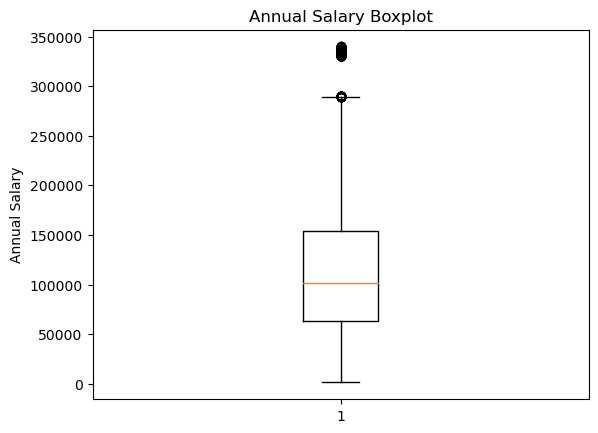

In [407]:
# Create boxplot to show Annual Salary Outliers

plt.boxplot(employee_df["AnnualSalary"])
plt.title("Annual Salary Boxplot")
plt.ylabel("Annual Salary")
plt.show()

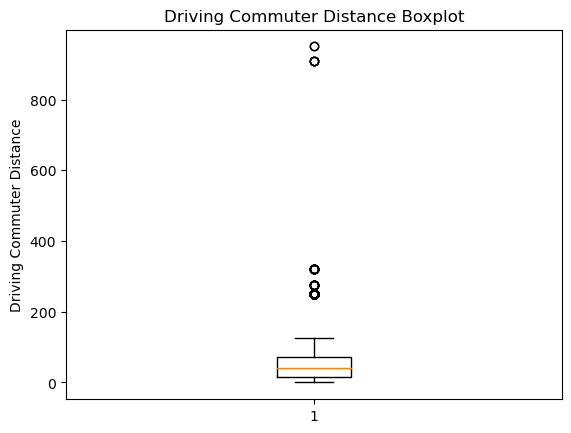

In [364]:
# Create boxplot to show Driving Commuter Distance Outliers

plt.boxplot(employee_df["DrivingCommuterDistance"])
plt.title("Driving Commuter Distance Boxplot")
plt.ylabel("Driving Commuter Distance")
plt.show()

In [409]:
#Identify AnnualSalary outlier thresholds

Q1 = employee_df["AnnualSalary"].quantile(0.25)
Q3 = employee_df["AnnualSalary"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [410]:
#Count AnnualSalary Outliers

salary_outliers = (
    (employee_df["AnnualSalary"] < lower_limit) |
    (employee_df["AnnualSalary"] > upper_limit)
).sum()

print("AnnualSalary outliers found:", salary_outliers)

AnnualSalary outliers found: 571


In [411]:
#Get Median for AnnualSalary and replace outliers with median
salary_median = employee_df.loc[
    (employee_df["AnnualSalary"] >= lower_limit) &
    (employee_df["AnnualSalary"] <= upper_limit),
    "AnnualSalary"
].median()

employee_df.loc[
    (employee_df["AnnualSalary"] < lower_limit) |
    (employee_df["AnnualSalary"] > upper_limit),
    "AnnualSalary"
] = salary_median

In [368]:
#Identify DrivingCommuterDistance outlier thresholds

Q1 = employee_df["DrivingCommuterDistance"].quantile(0.25)
Q3 = employee_df["DrivingCommuterDistance"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [369]:
#Count DrivingCommuterDistance outliers
distance_outliers = (
    (employee_df["DrivingCommuterDistance"] < lower_limit) |
    (employee_df["DrivingCommuterDistance"] > upper_limit)
).sum()

print("DrivingCommuterDistance outliers found:", distance_outliers)

DrivingCommuterDistance outliers found: 222


In [370]:
#Get Median for DrivingCommuterDistance and replace outliers with median

distance_median = employee_df.loc[
    (employee_df["DrivingCommuterDistance"] >= lower_limit) &
    (employee_df["DrivingCommuterDistance"] <= upper_limit),
    "DrivingCommuterDistance"
].median()

employee_df.loc[
    (employee_df["DrivingCommuterDistance"] < lower_limit) |
    (employee_df["DrivingCommuterDistance"] > upper_limit),
    "DrivingCommuterDistance"
] = distance_median

In [412]:
#Validate Outliers are removed for AnnualSalary

(
    (employee_df["AnnualSalary"] < lower_limit) |
    (employee_df["AnnualSalary"] > upper_limit)
).sum()

0

In [372]:
#Validate Outliers are removed for DrvingCommuterDistance
(
    (employee_df["DrivingCommuterDistance"] < lower_limit) |
    (employee_df["DrivingCommuterDistance"] > upper_limit)
).sum()

0

In [413]:
employee_df.to_csv("Cleaned_Employee_Turnover_Dataset.csv", index=False)